# Student Habits and Academic Performance Prediction Using Linear Regression

## Assignment

# Project Workflow

The following steps are performed in this project:

1. Import Libraries
2. Load the Dataset
3. Explore the Dataset
4. Data Cleaning
5. Data Preprocessing
6. Exploratory Data Analysis (EDA)
7. Feature Selection
8. Train-Test Split
9. Import Linear Regression Model
10. Create the Model
11. Train the Model
12. Make Predictions
13. Evaluate the Model
14. Compare Actual and Predicted Exam Scores
15. Conclusion

# Step 1: Import Libraries

In [ ]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the Dataset

In [ ]:
# loading the student habits and performance dataset
df = pd.read_csv("student_habits_performance.csv")

# Step 3: Explore the Dataset

In [ ]:
# viewing the first 5 rows of the dataset
df.head(5)

  student_id  age  ... extracurricular_participation  exam_score
0      S1000   23  ...                           Yes        56.2
1      S1001   20  ...                            No       100.0
2      S1002   21  ...                            No        34.3
3      S1003   23  ...                           Yes        26.8
4      S1004   19  ...                            No        66.4

[5 rows x 16 columns]

In [ ]:
# checking the shape (rows, columns) of the dataset
df.shape

(1000, 16)

In [ ]:
# checking column names, data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [ ]:
# viewing a random sample row
df.sample(1)

    student_id  age  ... extracurricular_participation  exam_score
532      S1532   17  ...                           Yes        83.0

[1 rows x 16 columns]

In [ ]:
# statistical summary of numeric columns
df.describe()

             age  study_hours_per_day  ...  mental_health_rating   exam_score
count  1000.0000           1000.00000  ...           1000.000000  1000.000000
mean     20.4980              3.55010  ...              5.438000    69.601500
std       2.3081              1.46889  ...              2.847501    16.888564
min      17.0000              0.00000  ...              1.000000    18.400000
25%      18.7500              2.60000  ...              3.000000    58.475000
50%      20.0000              3.50000  ...              5.000000    70.500000
75%      23.0000              4.50000  ...              8.000000    81.325000
max      24.0000              8.30000  ...             10.000000   100.000000

[8 rows x 9 columns]

In [ ]:
# checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# checking for missing/null values in every column
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

# Step 4: Data Cleaning

In [ ]:
# dropping the student_id column as it does not help in prediction
df = df.drop("student_id", axis=1)

In [ ]:
# filling missing values in parental_education_level with the mode (most frequent value)
df["parental_education_level"] = df["parental_education_level"].fillna(df["parental_education_level"].mode()[0])

In [ ]:
# confirming there are no missing values left
df.isnull().sum()

age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

# Step 5: Data Preprocessing

### Convert categorical columns to numerical values so the model can use them

In [ ]:
df.gender.unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [ ]:
# encoding gender: Female = 0, Male = 1, Other = 2
df.gender = df.gender.map({"Female": 0, "Male": 1, "Other": 2})

In [ ]:
df.part_time_job.unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [ ]:
# encoding part_time_job: No = 0, Yes = 1
df.part_time_job = df.part_time_job.map({"No": 0, "Yes": 1})

In [ ]:
df.diet_quality.unique()

<StringArray>
['Fair', 'Good', 'Poor']
Length: 3, dtype: str

In [ ]:
# encoding diet_quality: Poor = 0, Fair = 1, Good = 2 (ordinal relationship)
df.diet_quality = df.diet_quality.map({"Poor": 0, "Fair": 1, "Good": 2})

In [ ]:
df.parental_education_level.unique()

<StringArray>
['Master', 'High School', 'Bachelor']
Length: 3, dtype: str

In [ ]:
# encoding parental_education_level: High School = 0, Bachelor = 1, Master = 2 (ordinal relationship)
df.parental_education_level = df.parental_education_level.map({"High School": 0, "Bachelor": 1, "Master": 2})

In [ ]:
df.internet_quality.unique()

<StringArray>
['Average', 'Poor', 'Good']
Length: 3, dtype: str

In [ ]:
# encoding internet_quality: Poor = 0, Average = 1, Good = 2 (ordinal relationship)
df.internet_quality = df.internet_quality.map({"Poor": 0, "Average": 1, "Good": 2})

In [ ]:
df.extracurricular_participation.unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
# encoding extracurricular_participation: No = 0, Yes = 1
df.extracurricular_participation = df.extracurricular_participation.map({"No": 0, "Yes": 1})

In [ ]:
# verifying all columns are now numeric
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   int64  
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   int64  
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   int64  
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   int64  
 11  internet_quality               1000 non-null   int64  
 12  mental_health_rating           1000 non-null   int64  
 13  

In [ ]:
df.sample(5)

     age  gender  ...  extracurricular_participation  exam_score
263   17       0  ...                              0        62.7
872   18       0  ...                              0        78.4
325   22       0  ...                              0        75.4
207   20       0  ...                              1        62.3
496   19       0  ...                              0        73.9

[5 rows x 15 columns]

# Step 6: Exploratory Data Analysis (EDA)

### Finding relationships between features and exam_score

In [ ]:
# correlation of every feature with exam_score
df.corr()

                                    age  ...  exam_score
age                            1.000000  ...   -0.008907
gender                         0.032902  ...   -0.002406
study_hours_per_day            0.003971  ...    0.825419
social_media_hours            -0.009151  ...   -0.166733
netflix_hours                 -0.001174  ...   -0.171779
part_time_job                 -0.011680  ...   -0.026608
attendance_percentage         -0.026055  ...    0.089836
sleep_hours                    0.037482  ...    0.121683
diet_quality                   0.004117  ...    0.015018
exercise_frequency            -0.003836  ...    0.160107
parental_education_level       0.015994  ...   -0.021647
internet_quality               0.007799  ...   -0.036298
mental_health_rating          -0.045101  ...    0.321523
extracurricular_participation -0.004993  ...    0.000881
exam_score                    -0.008907  ...    1.000000

[15 rows x 15 columns]

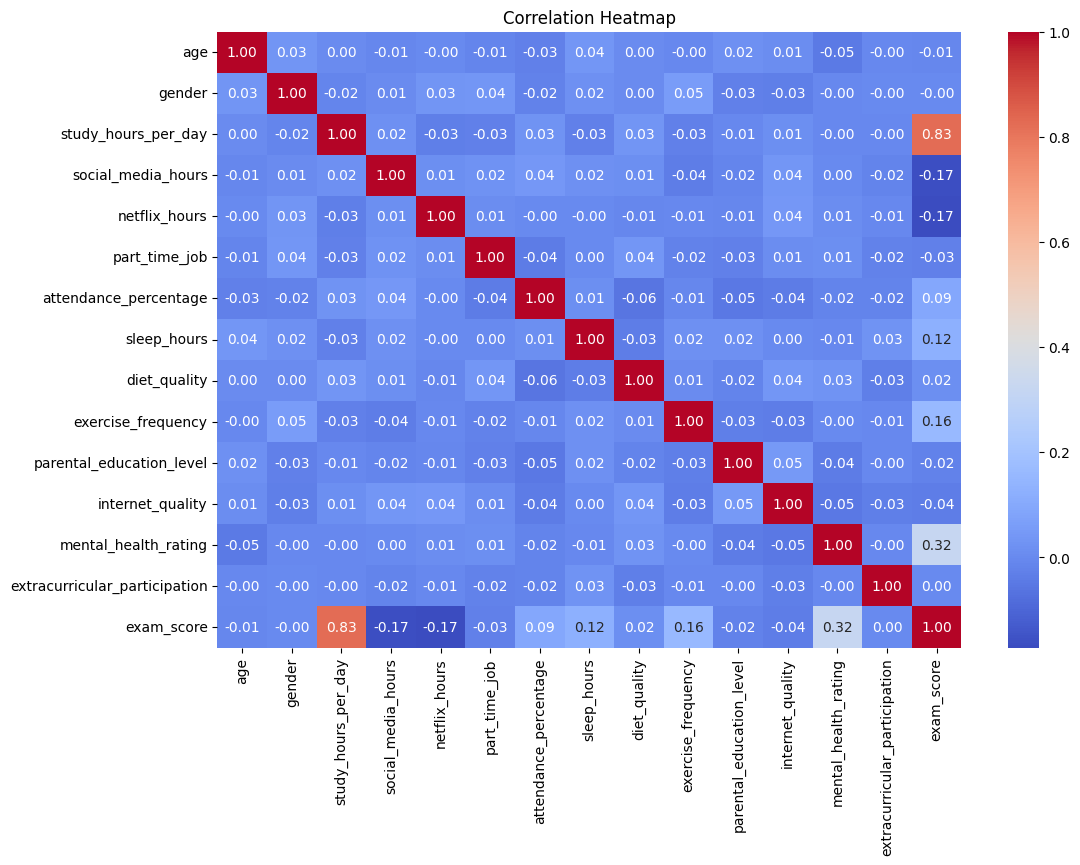

In [ ]:
# visualizing correlation between all features as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Feature vs Exam Score Graphs

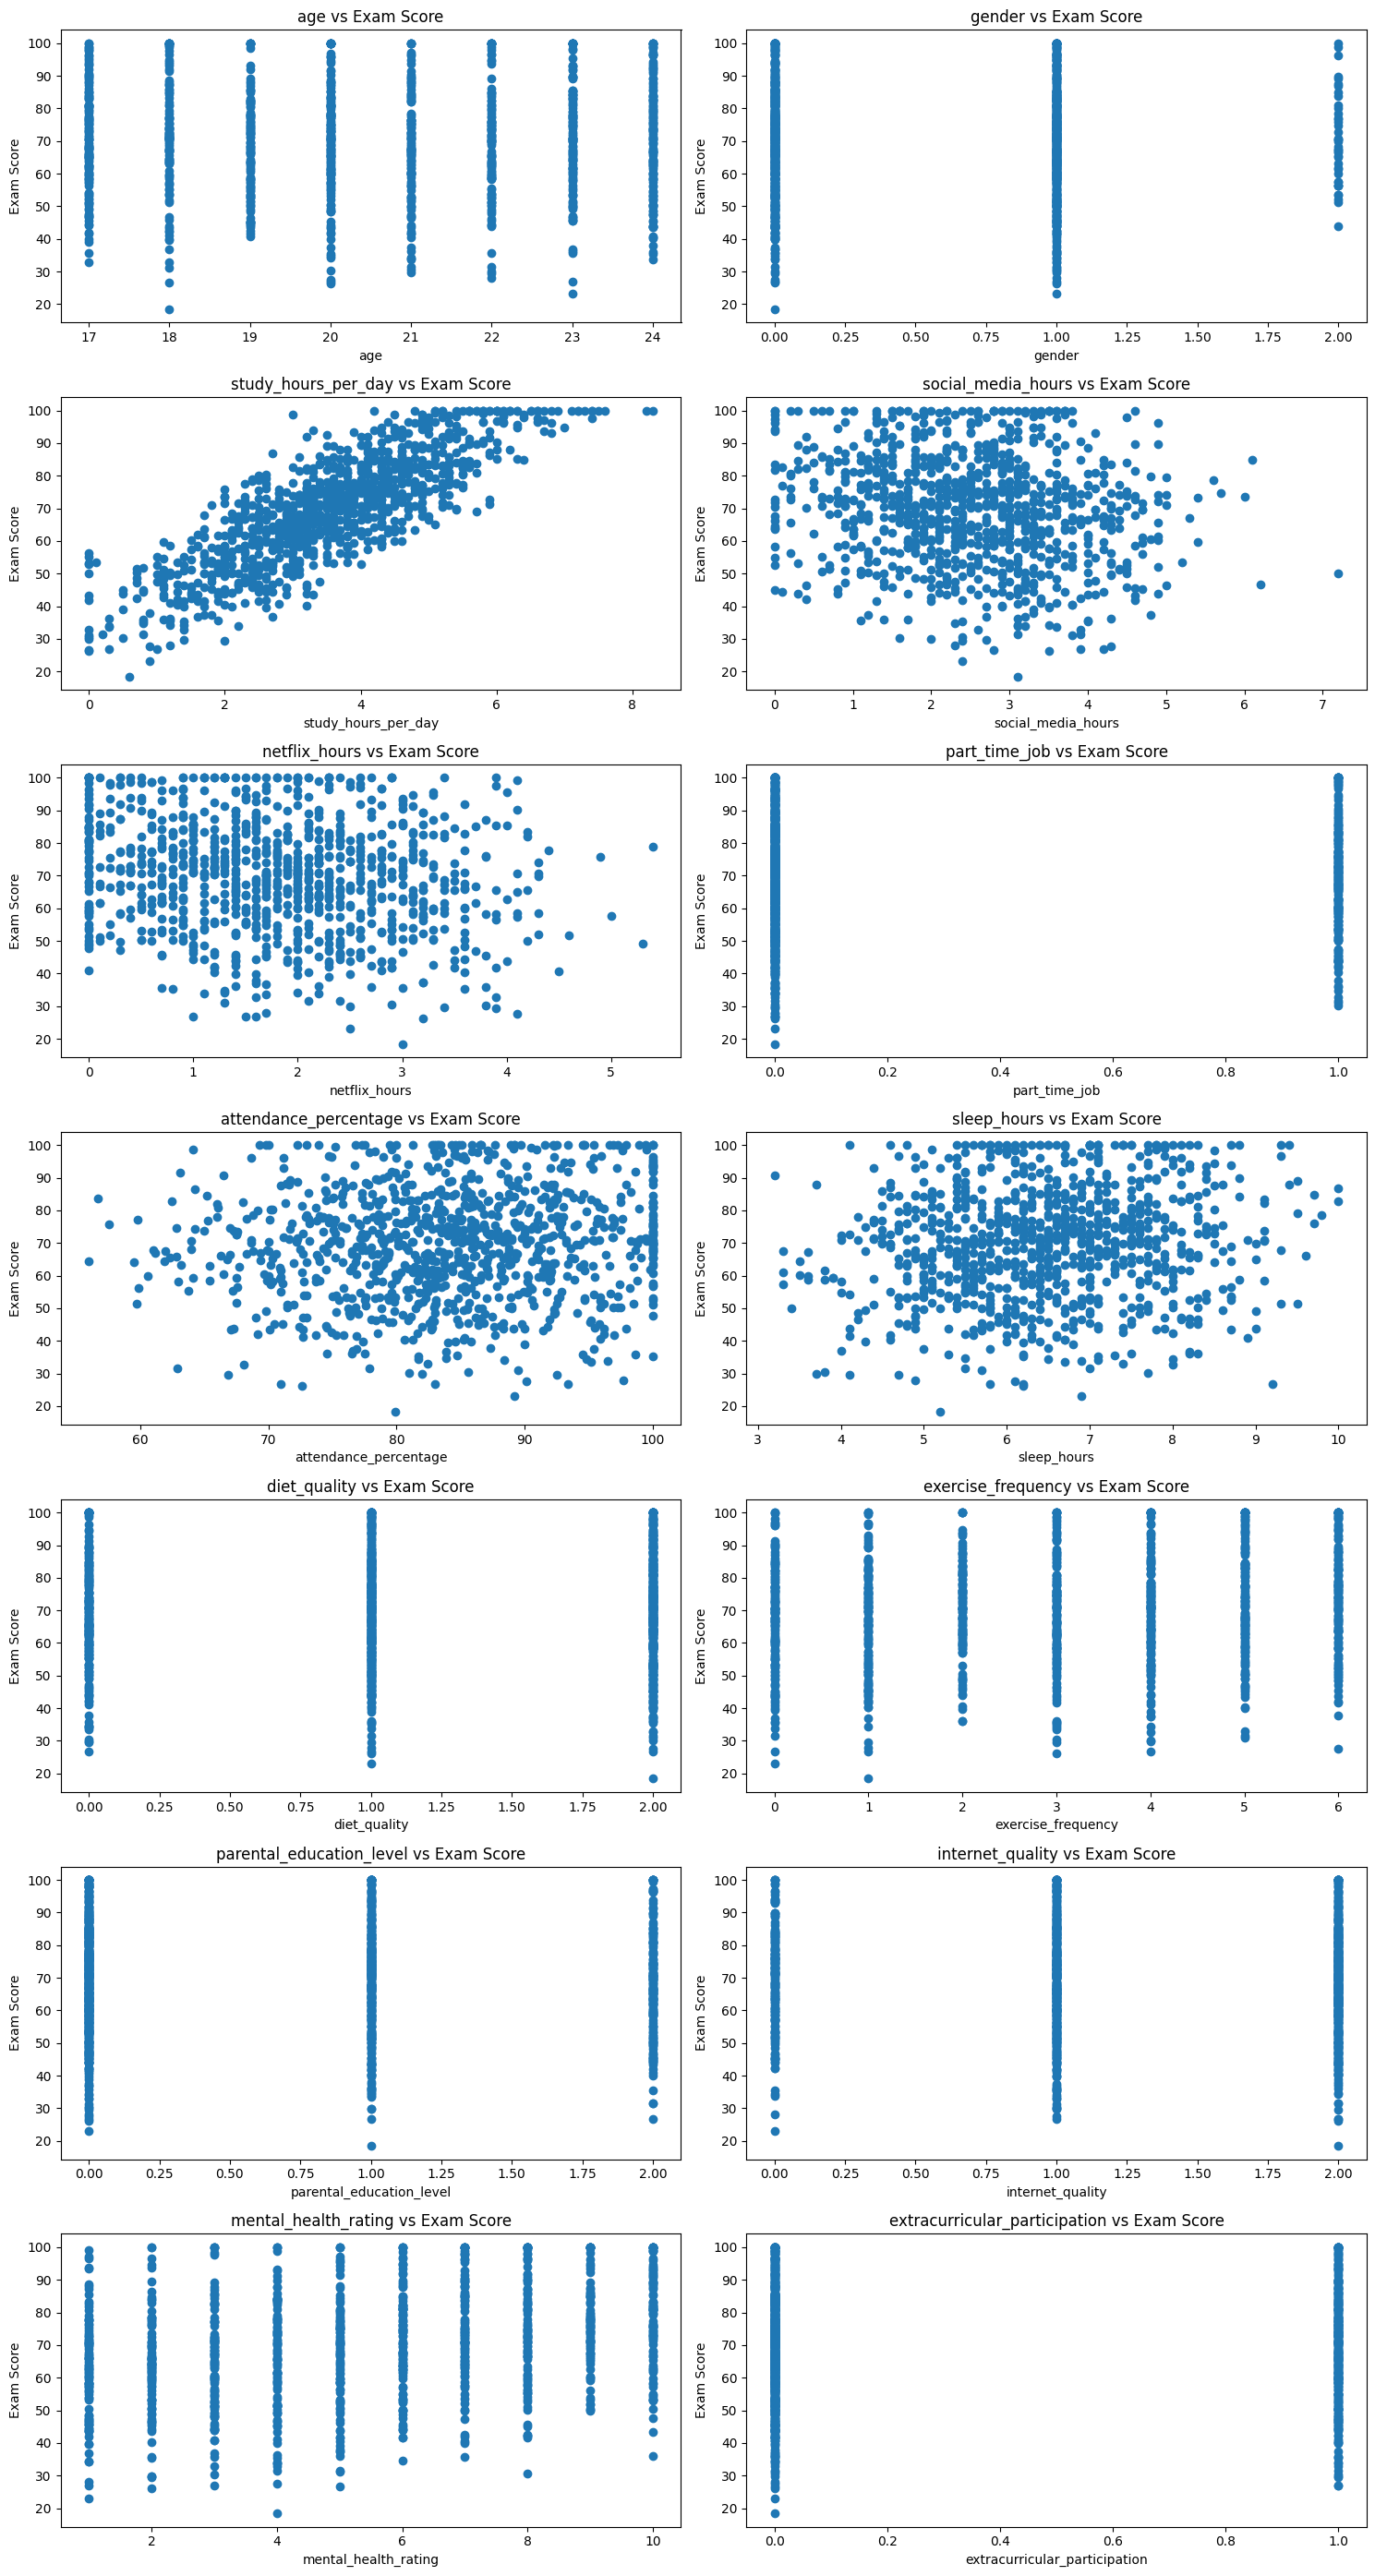

In [ ]:
# scatter plot of every feature against exam_score
columns = df.drop("exam_score", axis=1).columns
rows = (len(columns) + 1) // 2

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(columns, 1):
    plt.subplot(rows, 2, i)
    plt.scatter(df[col], df["exam_score"])
    plt.xlabel(col)
    plt.ylabel("Exam Score")
    plt.title(f"{col} vs Exam Score")
plt.tight_layout()
plt.show()

# Machine Learning Pipeline

# Step 7: Feature Selection
input x and y

In [ ]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [ ]:
X.shape

(1000, 14)

In [ ]:
y.shape

(1000,)

# Step 8: Train-Test Split

separate test and train data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape

(700, 14)

In [ ]:
X_test.shape

(300, 14)

# Step 9: Importing the Model and Evaluation Metrics

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Step 10: Creating the Linear Regression Model

In [ ]:
model = LinearRegression()

# Step 11: Training the Model

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

# Step 12: Making Predictions

In [ ]:
y_pred = model.predict(X_test)

# Step 13: Model Evaluation

The model's performance is evaluated using MAE, MSE, RMSE, and R² Score.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE  : 4.237995368077498
MSE  : 28.46105998133095
RMSE : 5.334890812503191
R² Score : 0.8975341523536073


# Actual vs Predicted Exam Scores

We compare the actual exam scores with the predicted scores generated by the model.

In [ ]:
results = pd.DataFrame({
    "Actual Exam Score": y_test,
    "Predicted Exam Score": y_pred
})

results.head(10)

     Actual Exam Score  Predicted Exam Score
521               64.2             66.418191
737               72.7             74.846388
740               79.0             78.422432
660               79.5             73.852542
411               58.2             61.171929
678               53.4             54.886920
626               70.8             75.755298
513               62.5             55.192547
859               36.8             41.157520
136               67.6             72.650630

# Actual vs Predicted Exam Score (Scatter Plot)

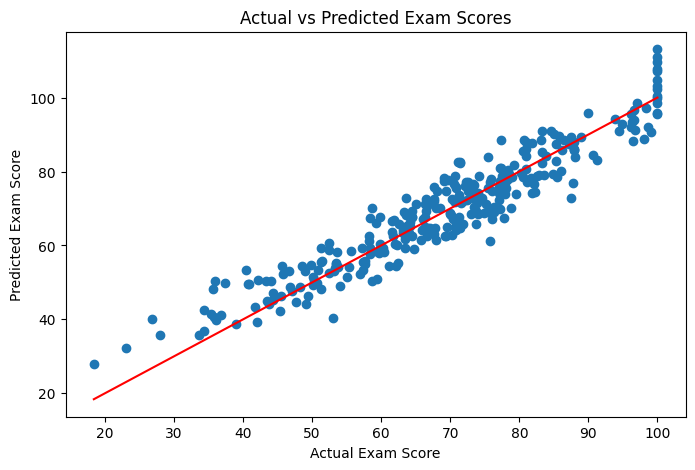

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.show()

# Residual Plot

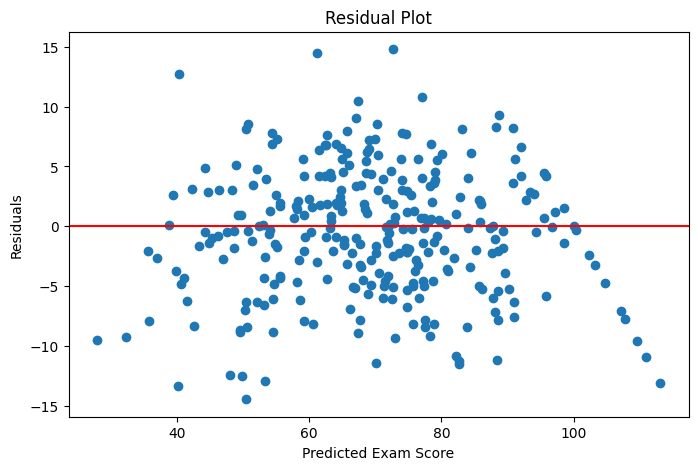

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color="red")
plt.show()

# Step 14: Model Performance on Training and Testing Data

In [ ]:
model.score(X_train, y_train)

0.901476207234156

In [ ]:
model.score(X_test, y_test)

0.8975341523536073

In [ ]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training Score :", train_score)
print("Testing Score  :", test_score)

Training Score : 0.901476207234156
Testing Score  : 0.8975341523536073


# Feature Importance (Model Coefficients)

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients

                          Feature  Coefficient
2             study_hours_per_day     9.602156
7                     sleep_hours     2.007643
12           mental_health_rating     1.943926
9              exercise_frequency     1.279183
1                          gender     0.319856
10       parental_education_level     0.271744
6           attendance_percentage     0.147301
0                             age     0.065356
5                   part_time_job     0.033827
11               internet_quality    -0.051590
13  extracurricular_participation    -0.124068
8                    diet_quality    -0.337988
4                   netflix_hours    -2.369750
3              social_media_hours    -2.740170

# Step 16: Predict Exam Score for a New Student (User Input)



In [ ]:
# taking input from the user for each feature

print("Enter the student's details below:\n")

age = int(input("Age: "))

gender_input = input("Gender (Female/Male/Other): ").strip().capitalize()
gender_map = {"Female": 0, "Male": 1, "Other": 2}
gender = gender_map[gender_input]

study_hours_per_day = float(input("Study hours per day: "))
social_media_hours = float(input("Social media hours per day: "))
netflix_hours = float(input("Netflix hours per day: "))

part_time_job_input = input("Part-time job (Yes/No): ").strip().capitalize()
part_time_job_map = {"No": 0, "Yes": 1}
part_time_job = part_time_job_map[part_time_job_input]

attendance_percentage = float(input("Attendance percentage: "))
sleep_hours = float(input("Sleep hours per day: "))

diet_quality_input = input("Diet quality (Poor/Fair/Good): ").strip().capitalize()
diet_quality_map = {"Poor": 0, "Fair": 1, "Good": 2}
diet_quality = diet_quality_map[diet_quality_input]

exercise_frequency = int(input("Exercise frequency (times per week): "))

parental_education_input = input("Parental education level (High School/Bachelor/Master): ").strip().title()
parental_education_map = {"High School": 0, "Bachelor": 1, "Master": 2}
parental_education_level = parental_education_map[parental_education_input]

internet_quality_input = input("Internet quality (Poor/Average/Good): ").strip().capitalize()
internet_quality_map = {"Poor": 0, "Average": 1, "Good": 2}
internet_quality = internet_quality_map[internet_quality_input]

mental_health_rating = int(input("Mental health rating (1-10): "))

extracurricular_input = input("Extracurricular participation (Yes/No): ").strip().capitalize()
extracurricular_map = {"No": 0, "Yes": 1}
extracurricular_participation = extracurricular_map[extracurricular_input]

In [ ]:
# building a single-row dataframe with the same column order as X

new_student = pd.DataFrame([{
    "age": age,
    "gender": gender,
    "study_hours_per_day": study_hours_per_day,
    "social_media_hours": social_media_hours,
    "netflix_hours": netflix_hours,
    "part_time_job": part_time_job,
    "attendance_percentage": attendance_percentage,
    "sleep_hours": sleep_hours,
    "diet_quality": diet_quality,
    "exercise_frequency": exercise_frequency,
    "parental_education_level": parental_education_level,
    "internet_quality": internet_quality,
    "mental_health_rating": mental_health_rating,
    "extracurricular_participation": extracurricular_participation
}])

# reordering columns to exactly match the training data
new_student = new_student[X.columns]
new_student

In [ ]:
# predicting the exam score for the new student
predicted_score = model.predict(new_student)[0]

# exam scores are capped between 0 and 100
predicted_score = max(0, min(100, predicted_score))

print(f"Predicted Exam Score: {predicted_score:.2f}")